# Subtask 1 — EDA (Notebook 1 of 5)

**Goal:** Understand the AgriPotential dataset before writing any model code.

**HITL gate:** After running this notebook, VB reviews the plots and tells Claude:
- Which timeframes (months) look most discriminative
- How severe the class imbalance is
- Whether patches cluster spatially by class

This informs feature selection in Notebook 2.

**Metric:** Accuracy±1 — a prediction within 1 ordinal class of truth counts as correct.

## 0. Setup

In [1]:
# Install dependencies (uncomment if running on fresh Colab/RunPod)
#!pip install -q rasterio pillow tqdm scipy
#!pip install matplotlib
#!pip install -q git+https://github.com/MohammadElSakka/agripotential

import csv
import json
import os
from pathlib import Path
from urllib.parse import urljoin
from urllib.request import urlopen
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── REPO ROOT — works whether JupyterLab cwd is project root or notebooks/ ──
#_cwd = Path(os.getcwd())
#REPO_ROOT = _cwd if (_cwd / "scripts").exists() else _cwd.parent
REPO_ROOT = "/workspace/ai4agri" #_cwd if (_cwd / "scripts").exists() else _cwd.parent
REPO_ROOT = Path(REPO_ROOT)

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_DIR   = None   # e.g. "/workspace/ai4agri/data/subtask1"
LABEL_NAME = "viticulture"
HF_BASE    = "https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/"
OUT_DIR    = REPO_ROOT / "results" / "subtask1" / "inspection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = ["Nodata (0)", "Very Low (1)", "Low (2)", "Medium (3)", "High (4)", "Very High (5)"]
CLASS_COLORS = ["#808080", "#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

print(f"Repo root: {REPO_ROOT}")
print("Setup complete.")

Repo root: /workspace/ai4agri
Setup complete.


## 1. Metadata & Split Sizes

In [2]:
def ref(name):
    if DATA_DIR:
        return str(Path(DATA_DIR) / name)
    return urljoin(HF_BASE, name)

def read_csv(name):
    r = ref(name)
    if r.startswith("http"):
        with urlopen(r, timeout=60) as h:
            lines = [l.decode("utf-8") for l in h]
    else:
        lines = Path(r).read_text().splitlines()
    return list(csv.DictReader(lines))

metadata = read_csv("metadata.csv")
train_rows = read_csv("train.csv")
val_rows   = read_csv("val.csv")
test_rows  = read_csv("test.csv")

print(f"Metadata rows (timeframes): {len(metadata)}")
print(f"Train patches: {len(train_rows)}")
print(f"Val patches:   {len(val_rows)}")
print(f"Test patches:  {len(test_rows)}")
print(f"\nMetadata columns: {list(metadata[0].keys())}")
print(f"Patch columns:    {list(train_rows[0].keys())}")

Metadata rows (timeframes): 34
Train patches: 6329
Val patches:   781
Test patches:  800

Metadata columns: ['filename', 'day', 'month', 'year']
Patch columns:    ['patch_id', 'row', 'col', 'patch_size', 'n_annotated']


In [3]:
# Timeframe calendar
#!pip install pandas
#!pip install -q "numpy==1.26.4" "pandas==2.2.2"
#!pip install -q --upgrade "numpy<2.0" pandas
import pandas as pd

meta_df = pd.DataFrame(metadata)
meta_df["date"] = pd.to_datetime(
    meta_df[["year", "month", "day"]].rename(
        columns={"year": "year", "month": "month", "day": "day"}
    )
)
meta_df = meta_df.sort_values("date").reset_index(drop=True)
print(f"Date range: {meta_df['date'].min().date()} → {meta_df['date'].max().date()}")
print(meta_df[["date", "filename"]].to_string())
print(meta_df.shape)

Date range: 2017-01-03 → 2019-12-29
         date               filename
0  2017-01-03  T31TEJ_2017_01_03.tif
1  2017-03-29  T31TEJ_2017_03_29.tif
2  2017-06-17  T31TEJ_2017_06_17.tif
3  2017-07-07  T31TEJ_2017_07_07.tif
4  2017-07-17  T31TEJ_2017_07_17.tif
5  2017-08-21  T31TEJ_2017_08_21.tif
6  2017-09-20  T31TEJ_2017_09_20.tif
7  2017-10-05  T31TEJ_2017_10_05.tif
8  2017-10-10  T31TEJ_2017_10_10.tif
9  2017-10-30  T31TEJ_2017_10_30.tif
10 2017-11-14  T31TEJ_2017_11_14.tif
11 2017-11-19  T31TEJ_2017_11_19.tif
12 2017-12-24  T31TEJ_2017_12_24.tif
13 2018-01-28  T31TEJ_2018_01_28.tif
14 2018-04-18  T31TEJ_2018_04_18.tif
15 2018-06-27  T31TEJ_2018_06_27.tif
16 2018-07-07  T31TEJ_2018_07_07.tif
17 2018-07-27  T31TEJ_2018_07_27.tif
18 2018-08-06  T31TEJ_2018_08_06.tif
19 2018-08-26  T31TEJ_2018_08_26.tif
20 2018-09-20  T31TEJ_2018_09_20.tif
21 2018-10-25  T31TEJ_2018_10_25.tif
22 2018-12-29  T31TEJ_2018_12_29.tif
23 2019-01-03  T31TEJ_2019_01_03.tif
24 2019-02-27  T31TEJ_2019_02_27.tif
25

## 2. Class Distribution (pixel-level)

Pixel counts from 6329 training patches:
  Class 0 (Very Low (0)): 38,507,107  (37.1%)
  Class 1 (Low (1)): 15,416,308  (14.9%)
  Class 2 (Medium (2)): 12,788,160  (12.3%)
  Class 3 (High (3)): 15,201,738  (14.7%)
  Class 4 (Very High (4)): 11,234,481  (10.8%)
  Class 5 (Unknown): 10,546,542  (10.2%)


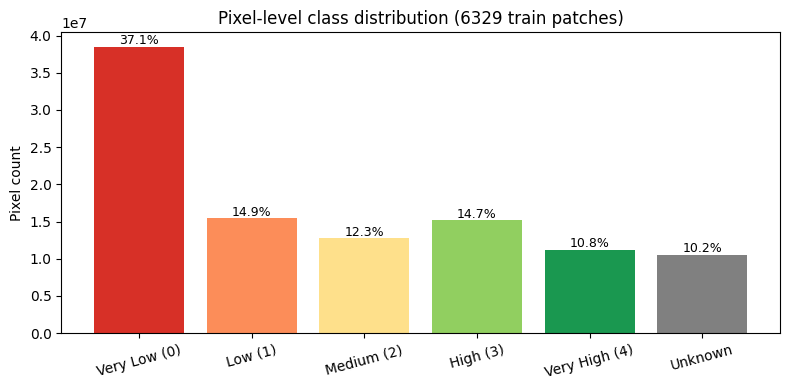

Saved → /workspace/ai4agri/results/subtask1/inspection/class_distribution.png


In [4]:
# Read label windows for a sample of training patches and accumulate class counts.
# Set LABEL_SAMPLE_LIMIT to control how many patches to read (each is 128×128).
LABEL_SAMPLE_LIMIT = 6329  # increase if data is local


import rasterio
from rasterio.windows import Window
HAS_RASTERIO = True

label_ref = ref(f"{LABEL_NAME}.tif")
class_counts = Counter()

if HAS_RASTERIO:
    with rasterio.open(label_ref) as src:
        for patch in train_rows[:LABEL_SAMPLE_LIMIT]:
            row, col, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            win = Window(col, row, ps, ps)
            label = src.read(1, window=win).astype(np.uint8)
            class_counts.update(label.ravel().tolist())
    print(f"Pixel counts from {LABEL_SAMPLE_LIMIT} training patches:")
    total = sum(class_counts.values())
    for k in range(6):
        n = class_counts.get(k, 0)
        print(f"  Class {k} ({CLASS_NAMES[k]}): {n:>8,d}  ({100*n/total:.1f}%)")

    fig, ax = plt.subplots(figsize=(8, 4))
    counts = [class_counts.get(k, 0) for k in range(6)]
    bars = ax.bar(range(6), counts, color=CLASS_COLORS)
    ax.set_xticks(range(6))
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_ylabel("Pixel count")
    ax.set_title(f"Pixel-level class distribution ({LABEL_SAMPLE_LIMIT} train patches)")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.003,
                f"{100*cnt/total:.1f}%", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "class_distribution.png", dpi=120)
    plt.show()
    print(f"Saved → {OUT_DIR}/class_distribution.png")
else:
    print("Install rasterio to read label distributions.")

## 3. Temporal Reflectance Profiles per Class

For each of the 5 ordinal classes (Very Low → Very High suitability), samples up to
  `TEMPORAL_SAMPLE_LIMIT` training patches and reads the actual Sentinel-2 image rasters
  across all 34 timeframes. For each patch, the majority class label (from `viticulture.tif`)
  determines which class bucket it falls into. Per-pixel reflectance values are collected
  for 3 representative bands (B1, B4/Red, B8/NIR by default) at every timeframe, then
  averaged into a mean reflectance curve per class.

  The output is a multi-panel line plot (`temporal_profiles.png`) — one panel per band —
  showing how each class's mean reflectance evolves across the calendar year. Curves that
  separate cleanly in summer (peak vigour) or winter (bare soil) confirm that raw band
  features carry temporal discriminative signal. Curves that overlap everywhere indicate
  a band is not useful without phenology engineering.

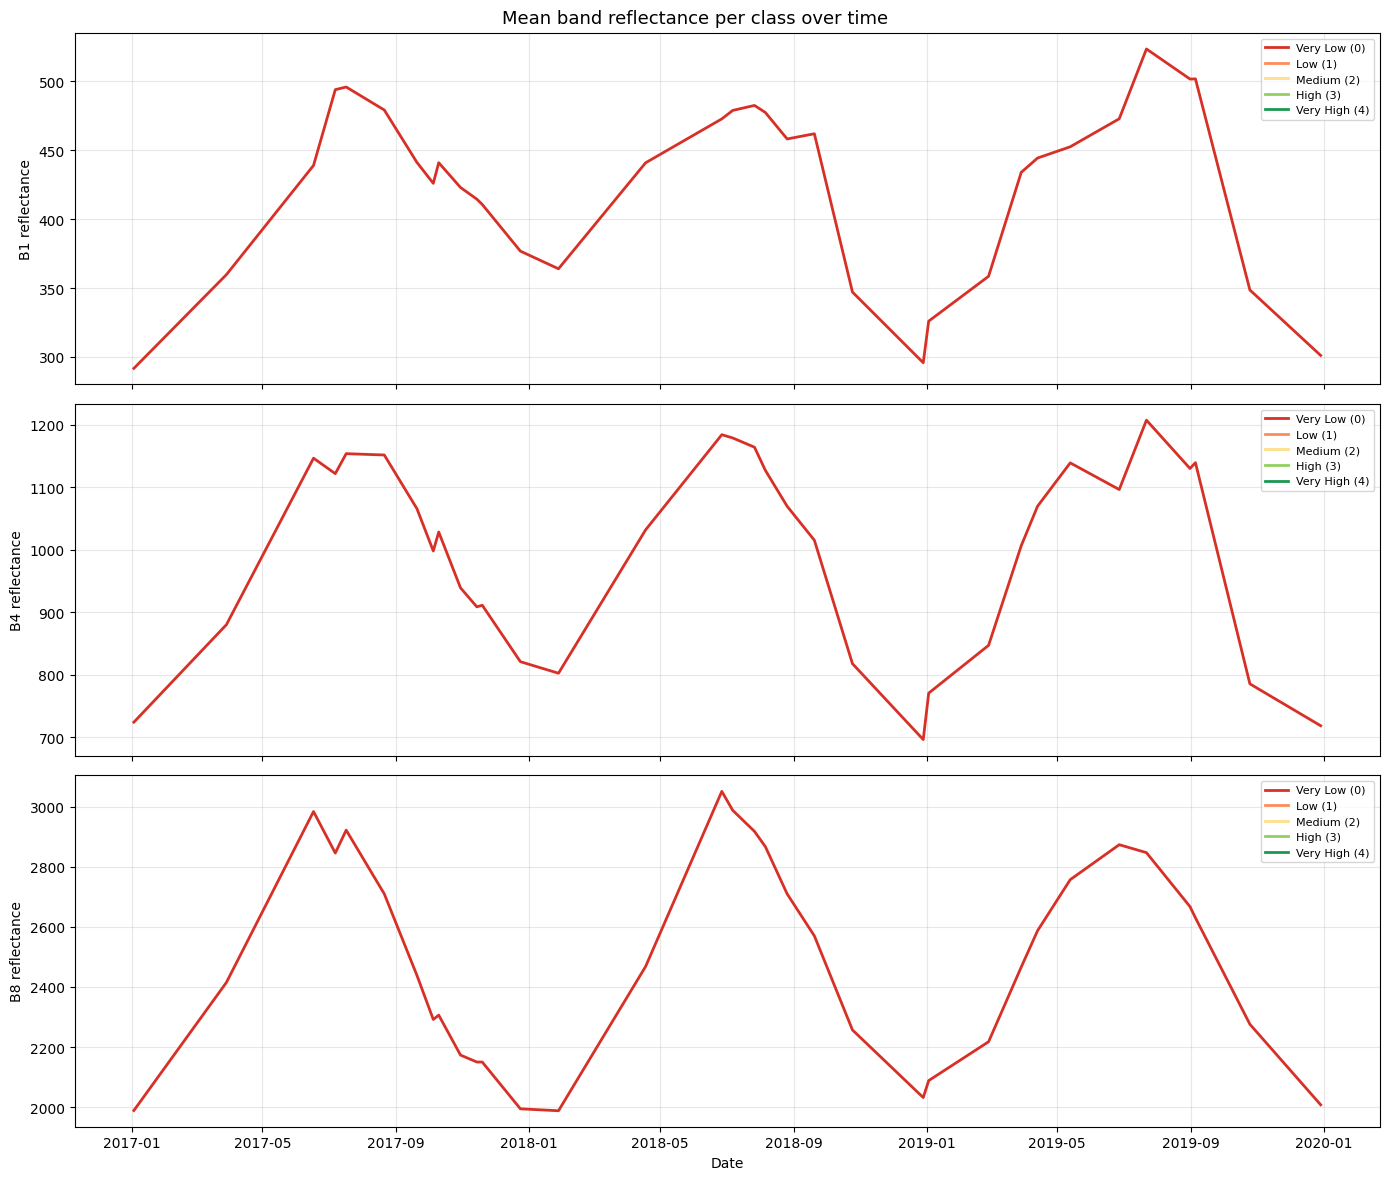

Saved → /workspace/ai4agri/results/subtask1/inspection/temporal_profiles.png

Patches sampled per class: {0: 5}


In [5]:
# For each class, read pixels from a sample of patches and collect mean band reflectance
# per timeframe. This shows which months / seasons separate classes.
TEMPORAL_SAMPLE_LIMIT = 5   # patches per class; reduce if slow
BANDS_TO_PLOT = [0, 2, 6]    # B2 (Blue), B4 (Red), B8 (NIR broad)
BAND_NAMES   = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]

if HAS_RASTERIO:
    #sentinel_files = [row["filename"] for row in meta_df.itertuples(index=False) if hasattr(row, 'filename')]
    # Use sorted metadata filenames
    sentinel_files = list(meta_df["filename"])
    n_times = len(sentinel_files)

    # Accumulate: class_profiles[cls][t][band] = list of pixel values
    from collections import defaultdict
    class_profiles = {c: [[[] for _ in range(10)] for _ in range(n_times)] for c in range(6)}
    class_patch_counts = Counter()

    with rasterio.open(label_ref) as lsrc:
        for patch in train_rows[:TEMPORAL_SAMPLE_LIMIT * 5]:
            row_idx, col_idx, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            win = Window(col_idx, row_idx, ps, ps)
            label = lsrc.read(1, window=win).astype(np.uint8)
            majority_cls = int(Counter(label.ravel().tolist()).most_common(1)[0][0])
            if majority_cls not in class_profiles:   # skip nodata / out-of-range labels
                continue
  
            if class_patch_counts[majority_cls] >= TEMPORAL_SAMPLE_LIMIT:
                continue
                
            class_patch_counts[majority_cls] += 1
            for t, fname in enumerate(sentinel_files):
                with rasterio.open(ref(fname)) as ssrc:
                    arr = ssrc.read(window=win).astype(np.float32)  # (10, H, W)
                for b in range(10):
                    class_profiles[majority_cls][t][b].append(float(np.nanmean(arr[b])))
            if all(v >= TEMPORAL_SAMPLE_LIMIT for v in class_patch_counts.values()):
                break

    dates = list(meta_df["date"])
    fig, axes = plt.subplots(len(BANDS_TO_PLOT), 1, figsize=(14, 4 * len(BANDS_TO_PLOT)), sharex=True)
    if len(BANDS_TO_PLOT) == 1:
        axes = [axes]
    for ax, b_idx in zip(axes, BANDS_TO_PLOT):
        for cls in range(6):
            means = [np.mean(class_profiles[cls][t][b_idx]) if class_profiles[cls][t][b_idx] else np.nan
                     for t in range(n_times)]
            ax.plot(dates, means, label=CLASS_NAMES[cls], color=CLASS_COLORS[cls], linewidth=2)
        ax.set_ylabel(f"{BAND_NAMES[b_idx]} reflectance")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Date")
    fig.suptitle("Mean band reflectance per class over time", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "temporal_profiles.png", dpi=120)
    plt.show()
    print(f"Saved → {OUT_DIR}/temporal_profiles.png")
    print("\nPatches sampled per class:", dict(class_patch_counts))
else:
    print("rasterio required for temporal profiles.")

## 4. Spatial Distribution of Patches by Majority Class

 Reads up to 2000 training patches from train.csv and, for each, opens the label raster (viticulture.tif) to find that patch's majority class. It then plots each patch as a dot at
  its (col, row) pixel coordinate in the full raster — coloured by majority class.

  The result (spatial_distribution.png) is a map of the vineyard region showing where each suitability class lives in geographic space. The key question it answers: do the classes
  cluster spatially, or are they interleaved?

  If classes form large contiguous blobs, a model trained on one part of the raster may simply have never seen certain terrain types — and that's the likely explanation for the
  val→test gap. If they're interleaved, the gap comes from something else (nodata, temporal shift, etc.).

  This is the single most diagnostic plot for understanding why submitted test scores have been ~30pp below validation scores.

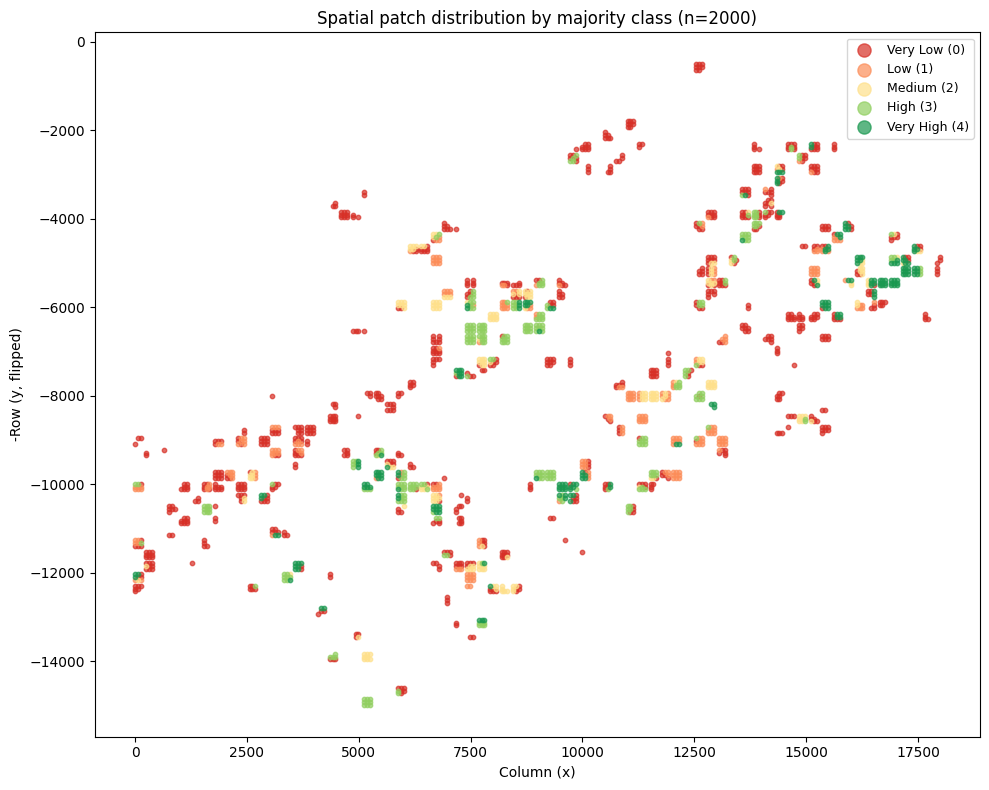

Saved → /workspace/ai4agri/results/subtask1/inspection/spatial_distribution.png


In [6]:
# Scatter plot of (col, row) for training patches coloured by majority class.
# Reveals whether classes cluster spatially (important for split strategy).
SPATIAL_LIMIT = 2000

if HAS_RASTERIO:
    spatial_cls = []
    spatial_rows = []
    spatial_cols = []
    with rasterio.open(label_ref) as lsrc:
        for patch in train_rows[:SPATIAL_LIMIT]:
            r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            lbl = lsrc.read(1, window=Window(c, r, ps, ps)).ravel()
            maj = int(Counter(lbl.tolist()).most_common(1)[0][0])
            spatial_cls.append(maj)
            spatial_rows.append(r)
            spatial_cols.append(c)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cls in range(6):
        mask = [i for i, c in enumerate(spatial_cls) if c == cls]
        ax.scatter(
            [spatial_cols[i] for i in mask],
            [-spatial_rows[i] for i in mask],
            label=CLASS_NAMES[cls], color=CLASS_COLORS[cls], s=10, alpha=0.7
        )
    ax.set_xlabel("Column (x)"); ax.set_ylabel("-Row (y, flipped)")
    ax.set_title(f"Spatial patch distribution by majority class (n={SPATIAL_LIMIT})")
    ax.legend(markerscale=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "spatial_distribution.png", dpi=120)
    plt.show()
    print(f"Saved → {OUT_DIR}/spatial_distribution.png")
else:
    # Fallback: plot just patch positions without class colouring
    rows = [int(p["row"]) for p in train_rows[:SPATIAL_LIMIT]]
    cols = [int(p["col"]) for p in train_rows[:SPATIAL_LIMIT]]
    plt.figure(figsize=(8, 6))
    plt.scatter(cols, [-r for r in rows], s=5, alpha=0.5)
    plt.title("Training patch positions (no class colour — rasterio missing)")
    plt.xlabel("col"); plt.ylabel("-row")
    plt.tight_layout(); plt.show()

## 5. Per-Band × Per-Timeframe Correlation with Label

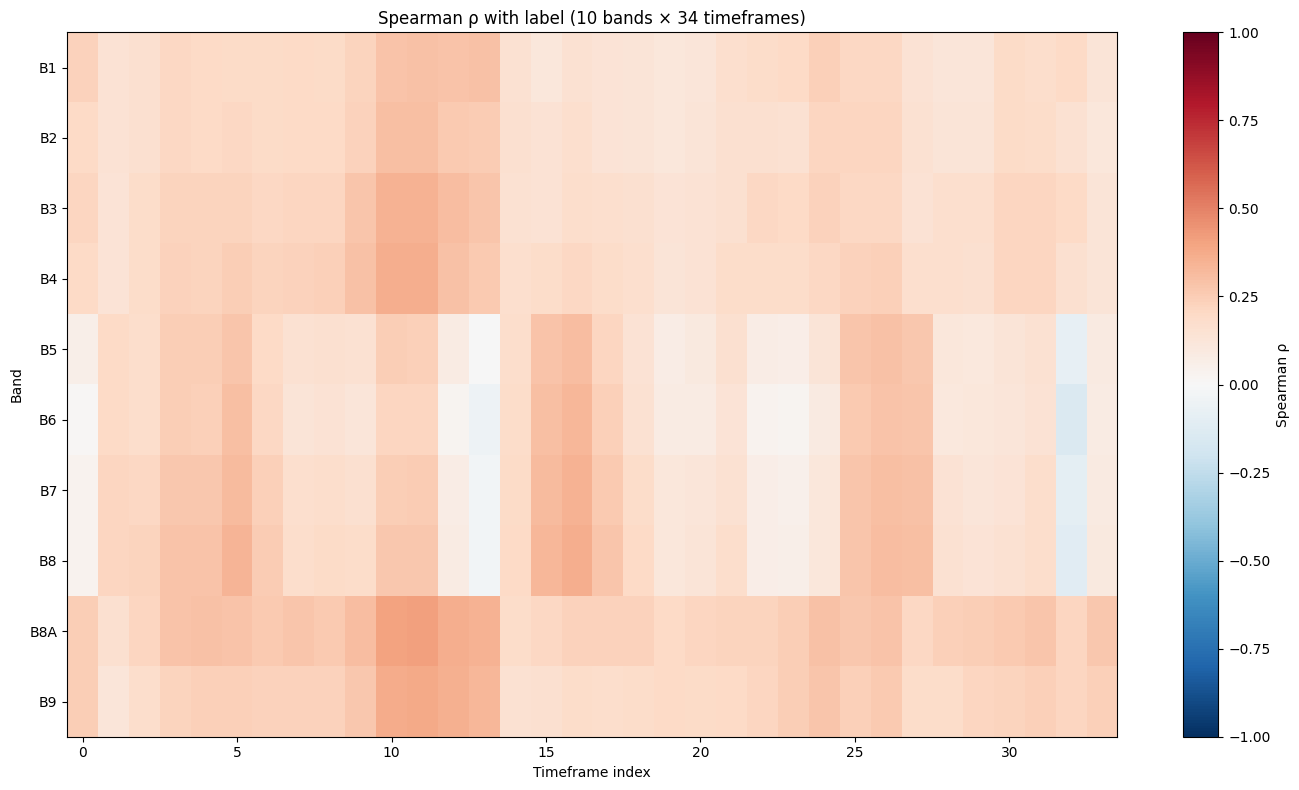

Saved → /workspace/ai4agri/results/subtask1/inspection/band_time_correlation.png

Top 10 features by |Spearman ρ|:
  Timeframe 11 (2017-11-19), Band B8A: ρ=0.409
  Timeframe 10 (2017-11-14), Band B8A: ρ=0.403
  Timeframe 11 (2017-11-19), Band B9: ρ=0.380
  Timeframe 10 (2017-11-14), Band B9: ρ=0.373
  Timeframe 16 (2018-07-07), Band B8: ρ=0.366
  Timeframe 11 (2017-11-19), Band B4: ρ=0.365
  Timeframe 12 (2017-12-24), Band B8A: ρ=0.364
  Timeframe 10 (2017-11-14), Band B4: ρ=0.360
  Timeframe 12 (2017-12-24), Band B9: ρ=0.358
  Timeframe 13 (2018-01-28), Band B8A: ρ=0.348


In [7]:
# Spearman correlation of each of the 340 features (10 bands × 34 timeframes)
# with the pixel label. High |ρ| = discriminative feature.
# Uses the sampled pixel data from class_profiles above.
CORR_LIMIT = 30  # patches to sample for correlation

if HAS_RASTERIO:
    from scipy.stats import spearmanr

    X_sample, y_sample = [], []
    with rasterio.open(label_ref) as lsrc:
        for patch in train_rows[:CORR_LIMIT]:
            r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            lbl = lsrc.read(1, window=Window(c, r, ps, ps)).astype(np.uint8)  # (H,W)
            # Stack all timeframes for this patch: (n_times, 10, H, W)
            frames = []
            for fname in sentinel_files:
                with rasterio.open(ref(fname)) as ssrc:
                    arr = ssrc.read(window=Window(c, r, ps, ps)).astype(np.float32)
                frames.append(arr)
            stack = np.stack(frames, axis=0)  # (T, 10, H, W)
            # Reshape to pixels: (H*W, T*10)
            T, B, H, W = stack.shape
            feats = stack.transpose(2, 3, 0, 1).reshape(H*W, T*B)
            X_sample.append(feats)
            y_sample.append(lbl.ravel())

    X_all = np.concatenate(X_sample, axis=0)
    y_all = np.concatenate(y_sample, axis=0)

    # Compute Spearman ρ for each of the 340 features
    rho = np.array([spearmanr(X_all[:, i], y_all).correlation for i in range(X_all.shape[1])])
    rho_matrix = rho.reshape(n_times, 10)  # (T, B)

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(rho_matrix.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_yticks(range(10))
    ax.set_yticklabels(BAND_NAMES)
    ax.set_xlabel("Timeframe index")
    ax.set_ylabel("Band")
    ax.set_title("Spearman ρ with label (10 bands × 34 timeframes)")
    plt.colorbar(im, ax=ax, label="Spearman ρ")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "band_time_correlation.png", dpi=120)
    plt.show()
    print(f"Saved → {OUT_DIR}/band_time_correlation.png")

    # Print top 10 most correlated feature indices
    top_idx = np.argsort(np.abs(rho))[-10:][::-1]
    print("\nTop 10 features by |Spearman ρ|:")
    for idx in top_idx:
        t_idx, b_idx = divmod(int(idx), 10)
        print(f"  Timeframe {t_idx:2d} ({str(dates[t_idx].date())}), Band {BAND_NAMES[b_idx]}: ρ={rho[idx]:.3f}")
else:
    print("rasterio required for correlation analysis.")

## 6. Sample Patch Visualisation

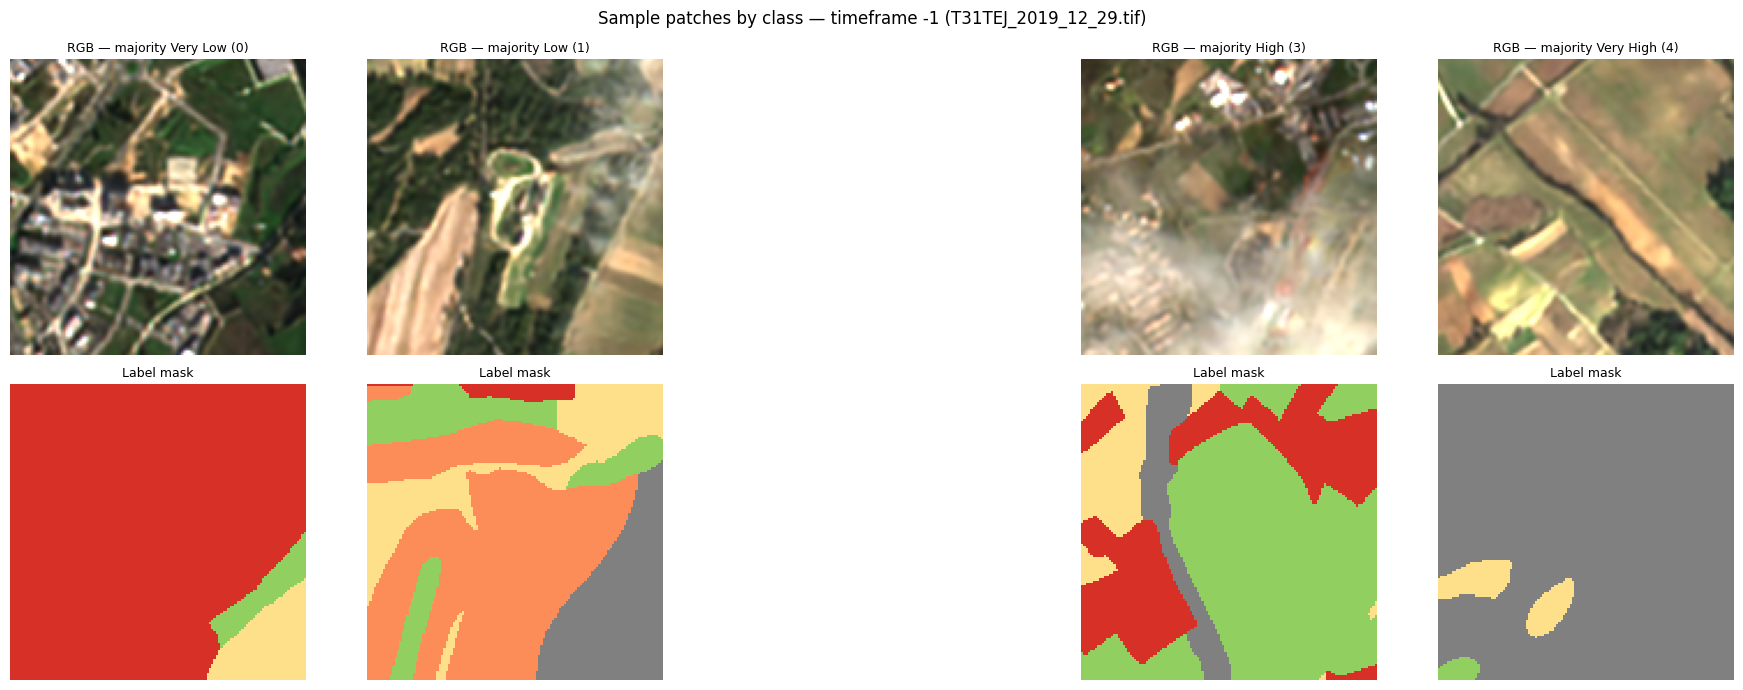

Saved → /workspace/ai4agri/results/subtask1/inspection/sample_patches.png


In [8]:
# Show one representative patch per class: RGB false-colour + label mask.
# Uses the last timeframe with the fewest clouds (pick timeframe index manually if needed).
VIS_TIMEFRAME = -1  # last timeframe; change to a specific index after HITL review
VIS_RGB_BANDS = [3, 2, 1]  # B4, B3, B2 → true colour

if HAS_RASTERIO:
    vis_file = sentinel_files[VIS_TIMEFRAME]
    cmap = mcolors.ListedColormap(CLASS_COLORS)
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

    # Find one patch per class
    sample_patches = {}
    with rasterio.open(label_ref) as lsrc:
        for patch in train_rows:
            if len(sample_patches) == 5:
                break
            r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            lbl = lsrc.read(1, window=Window(c, r, ps, ps)).ravel()
            maj = int(Counter(lbl.tolist()).most_common(1)[0][0])
            if maj not in sample_patches:
                sample_patches[maj] = patch

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for col_i, cls in enumerate(range(6)):
        if cls not in sample_patches:
            axes[0, col_i].axis("off")
            axes[1, col_i].axis("off")
            continue
        p = sample_patches[cls]
        r, c, ps = int(p["row"]), int(p["col"]), int(p["patch_size"])
        win = Window(c, r, ps, ps)
        with rasterio.open(ref(vis_file)) as ssrc:
            rgb_raw = ssrc.read(VIS_RGB_BANDS, window=win).astype(np.float32)  # (3,H,W)
        with rasterio.open(label_ref) as lsrc:
            lbl = lsrc.read(1, window=win).astype(np.uint8)

        rgb = np.clip(rgb_raw / np.percentile(rgb_raw, 98), 0, 1).transpose(1, 2, 0)
        axes[0, col_i].imshow(rgb)
        axes[0, col_i].set_title(f"RGB — majority {CLASS_NAMES[cls]}", fontsize=9)
        axes[0, col_i].axis("off")
        axes[1, col_i].imshow(lbl, cmap=cmap, norm=norm, interpolation="nearest")
        axes[1, col_i].set_title("Label mask", fontsize=9)
        axes[1, col_i].axis("off")

    plt.suptitle(f"Sample patches by class — timeframe {VIS_TIMEFRAME} ({vis_file})", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "sample_patches.png", dpi=120)
    plt.show()
    print(f"Saved → {OUT_DIR}/sample_patches.png")
else:
    print("rasterio required for patch visualisation.")

## 7. EDA Summary & HITL Handoff

After reviewing the plots above, please record:

1. **Class imbalance:** Is any class severely under-represented (< 5% of pixels)?  
   → If yes: use `class_weight='balanced'` in Notebook 2; oversample in Notebook 3.

2. **Discriminative timeframes:** Which 3–5 timeframe indices show the biggest separation between classes in the temporal profile plot?  
   → Record these for Notebook 2's seasonal feature grouping.

3. **Spatial clustering:** Do classes form large contiguous blocks in the spatial plot?  
   → If yes: use patch-level (not pixel-level) train/val splitting in Notebook 2.

4. **Band importance:** Which bands have the highest |Spearman ρ| in the heatmap?  
   → These are the priority bands for vegetation index features.

Share findings with Claude before proceeding to Notebook 2.

In [9]:
# Save a compact JSON summary for reference in subsequent notebooks
summary = {
    "n_timeframes": len(metadata),
    "n_train": len(train_rows),
    "n_val": len(val_rows),
    "n_test": len(test_rows),
    "class_names": CLASS_NAMES,
    "label_name": LABEL_NAME,
    "data_dir": DATA_DIR,
}
if HAS_RASTERIO and class_counts:
    total_px = sum(class_counts.values())
    summary["class_pixel_fractions"] = {str(k): round(class_counts.get(k, 0)/total_px, 4) for k in range(5)}

(OUT_DIR / "eda_summary.json").write_text(json.dumps(summary, indent=2))
print("EDA summary saved to", OUT_DIR / "eda_summary.json")
print(json.dumps(summary, indent=2))

EDA summary saved to /workspace/ai4agri/results/subtask1/inspection/eda_summary.json
{
  "n_timeframes": 34,
  "n_train": 6329,
  "n_val": 781,
  "n_test": 800,
  "class_names": [
    "Very Low (0)",
    "Low (1)",
    "Medium (2)",
    "High (3)",
    "Very High (4)",
    "Unknown"
  ],
  "label_name": "viticulture",
  "data_dir": null,
  "class_pixel_fractions": {
    "0": 0.3714,
    "1": 0.1487,
    "2": 0.1233,
    "3": 0.1466,
    "4": 0.1083
  }
}
